Benjamin Arnold; 09/20/2026; Lab 4: Two-Body Collisions.

Part A-- 1D Collisions with Restitution

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def collide_1d(m1,m2,u1,u2,e):
    M=m1+m2
    V=(u1*m1+u2*m2)/M

    v1=V-e*(m2/M)*(u1-u2)
    v2=V+e*(m1/M)*(u1-u2)

    return v1,v2

v10,v20=collide_1d(1,1,1,0,1)
v11,v21=collide_1d(0.1,100,1,0,1)
v12,v22=collide_1d(100,0.1,1,0,1)

print(f'First : Before: mass 1 is {1.00} kg with velocity {1.00} m/s, mass 2 is {1.00} kg with velocity {0.00} m/s.')
print(f'First : After : mass 1 is {1.00} kg with velocity {v10:.2f} m/s, mass 2 is {1} kg with velocity {v20:.2f} m/s.\n')

print(f'Second: Before: mass 1 is {0.10} kg with velocity {1.00} m/s, mass 2 is {100} kg with velocity {0.00} m/s.')
print(f'Second: After : mass 1 is {0.10} kg with velocity {v11:.2f} m/s, mass 2 is {100} kg with velocity {v21:.2f} m/s.\n')

print(f'Third : Before: mass 1 is {100} kg with velocity {1.00} m/s, mass 2 is {0.10} kg with velocity {0.00} m/s.')
print(f'Third : After : mass 1 is {100} kg with velocity {v12:.2f} m/s, mass 2 is {0.10} kg with velocity {v22:.2f} m/s.\n')

def computer(m1,m2,u1,u2,v1,v2):
    P_bef=m1*u1+m2*u2
    P_aft=m1*v1+m2*v2

    KE_bef=0.5*(m1*u1**2+m2*u2**2)
    KE_aft=0.5*(m1*v1**2+m2*v2**2)
    return P_bef,P_aft,KE_bef,KE_aft

v13,v23=collide_1d(2,3,4,0,1.0)
v14,v24=collide_1d(2,3,4,0,0.5)
v15,v25=collide_1d(2,3,4,0,0.0)

P1_bef,P1_aft,KE1_bef,KE1_aft=computer(2,3,4,0,v13,v23)
P2_bef,P2_aft,KE2_bef,KE2_aft=computer(2,3,4,0,v14,v24)
P0_bef,P0_aft,KE0_bef,KE0_aft=computer(2,3,4,0,v15,v25)

print(f'\nCollision Scenario: mass 1 is {2.0} kg with velocity {4.0} m/s, and mass 2 is {3.0} kg with velocity {0.0} m/s.\n')

print(f'(e={1.0}): Before: Energy is {KE1_bef:.2f} and Total Momenetum is {P1_bef:.2f}.')
print(f'(e={1.0}): After : Energy is {KE1_aft:.2f} and Total Momenetum is {P1_aft:.2f}.\n')

print(f'(e={0.5}): Before: Energy is {KE2_bef:.2f} and Total Momenetum is {P2_bef:.2f}.')
print(f'(e={0.5}): After : Energy is {KE2_aft:.2f} and Total Momenetum is {P2_aft:.2f}.\n')

print(f'(e={0.0}): Before: Energy is {KE0_bef:.2f} and Total Momenetum is {P0_bef:.2f}.')
print(f'(e={0.0}): After : Energy is {KE0_aft:.2f} and Total Momenetum is {P0_aft:.2f}.')

First : Before: mass 1 is 1.0 kg with velocity 1.0 m/s, mass 2 is 1.0 kg with velocity 0.0 m/s.
First : After : mass 1 is 1.0 kg with velocity 0.00 m/s, mass 2 is 1 kg with velocity 1.00 m/s.

Second: Before: mass 1 is 0.1 kg with velocity 1.0 m/s, mass 2 is 100 kg with velocity 0.0 m/s.
Second: After : mass 1 is 0.1 kg with velocity -1.00 m/s, mass 2 is 100 kg with velocity 0.00 m/s.

Third : Before: mass 1 is 100 kg with velocity 1.0 m/s, mass 2 is 0.1 kg with velocity 0.0 m/s.
Third : After : mass 1 is 100 kg with velocity 1.00 m/s, mass 2 is 0.1 kg with velocity 2.00 m/s.


Collision Scenario: mass 1 is 2.0 kg with velocity 4.0 m/s, and mass 2 is 3.0 kg with velocity 0.0 m/s.

(e=1.0): Before: Energy is 16.00 and Total Momenetum is 8.00.
(e=1.0): After : Energy is 16.00 and Total Momenetum is 8.00.

(e=0.5): Before: Energy is 16.00 and Total Momenetum is 8.00.
(e=0.5): After : Energy is 8.80 and Total Momenetum is 8.00.

(e=0.0): Before: Energy is 16.00 and Total Momenetum is 8.00.

Note: As the restitution gets smaller in a collision, there is greater loss of energy after the collision compared to before. This is because, in an inelastic collision, the two bodies stick to each other. Physically, this means that energy is lost in the form of heat, light, sound, and deformation of the two bodies.

Part B-- 2D Collisions in a Box

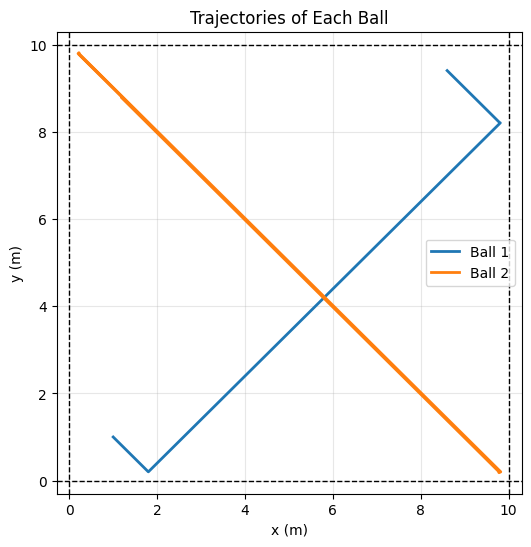

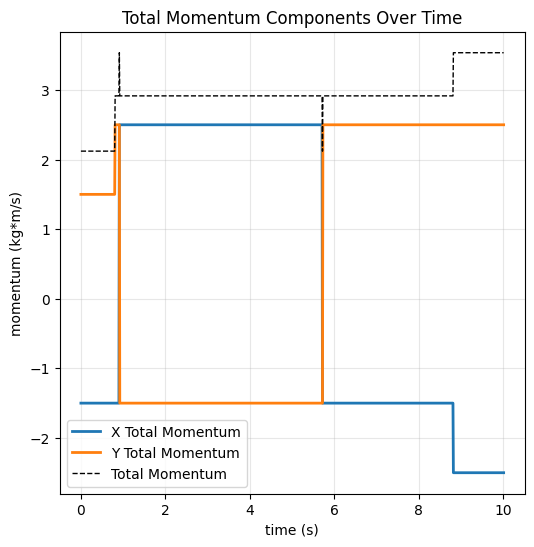

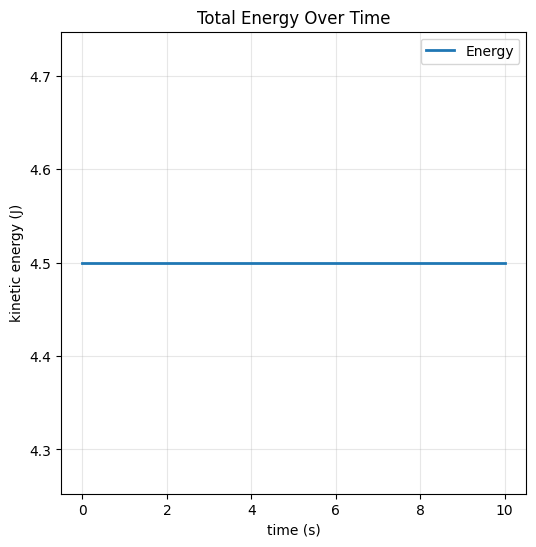

In [50]:
max_time=10
time_step=0.01
Rad1=0.1
Rad2=0.2
m1=0.5
m2=1
box=np.array([0,10,0,10,np.max([Rad1,Rad2])])

def overlapping(r1,r2,v1,v2,Rad1,Rad2):
    r1,r2=np.array(r1),np.array(r2)
    n=r2-r1
    d=np.sqrt(np.dot(n,n))

    App=np.dot(v2-v1,r2-r1)
    return d<(Rad1+Rad2) and App<0


def collide_2d(m1,m2,r1,r2,v1,v2,e):
    r1,r2=np.array(r1),np.array(r2)
    v1,v2=np.array(v1),np.array(v2)

    n=r2-r1
    d=(np.sqrt(np.dot(n,n)))
    if d==0:
        return v1,v2
    n=n/d

    v1n,v2n=np.dot(n,v1),np.dot(n,v2)
    v1t,v2t=(v1-v1n*n),(v2-v2n*n)

    v1n,v2n=collide_1d(m1,m2,v1n,v2n,e)

    nu1,nu2=(v1t+v1n*n),(v2t+v2n*n)
    return nu1,nu2

def simulate_walls(Rad1,Rad2,m1,m2,r1,r2,v1,v2,e,dt):
    t=0.0

    r1,r2=np.array(r1),np.array(r2)
    v1,v2=np.array(v1),np.array(v2)

    E=(0.5*m1)*(np.dot(v1,v1))+(0.5*m2)*(np.dot(v2,v2))
    P=m1*v1+m2*v2
    M=m1+m2
    V=P/M
    cen=(m1*r1+m2*r2)/M

    pos=np.array([r1,r2])
    vel=np.array([v1,v2])

    t_arr,pos_arr,vel_arr,cen_arr,V_arr,E_arr,P_arr=[t],[pos.copy()],[vel.copy()],[cen],[V],[E],[P]

    while (t<=max_time):
        r1, r2 = pos[0], pos[1]
        v1, v2 = vel[0], vel[1]

        if overlapping(r1,r2,v1,v2,Rad1,Rad2):
            v1,v2=collide_2d(m1,m2,r1,r2,v1,v2,e)
            vel[0], vel[1] = v1, v2

        left=pos[:,0]<box[0]+box[4]
        right=pos[:,0]>box[1]-box[4]
        bottom=pos[:,1]<box[2]+box[4]
        top=pos[:,1]>box[3]-box[4]

        vel[left,0]*=-1
        vel[right,0]*=-1
        vel[bottom,1]*=-1
        vel[top,1]*=-1

        pos[left,0]=box[0]+box[4]
        pos[right,0]=box[1]-box[4]
        pos[bottom,1]=box[2]+box[4]
        pos[top,1]=box[3]-box[4]

        pos[0]=pos[0]+vel[0]*dt
        pos[1]=pos[1]+vel[1]*dt

        E=(0.5*m1)*(np.dot(vel[0],vel[0]))+(0.5*m2)*(np.dot(vel[1],vel[1]))
        P=m1*vel[0]+m2*vel[1]
        M=m1+m2
        V=P/M
        cen=(m1*pos[0]+m2*pos[1])/M

        t=t+dt

        t_arr.append(t)
        pos_arr.append(pos.copy())
        vel_arr.append(vel.copy())
        cen_arr.append(cen)
        V_arr.append(V)
        E_arr.append(E)
        P_arr.append(P)
    return t_arr,pos_arr,vel_arr,cen,V_arr,E_arr,P_arr

r1,r2=np.array([1.0,1.0]),np.array([2.0,8.0])
v1,v2=np.array([1.0,-1.0]),np.array([-2.0,2.0])

t,pos,vel,cen,V,E,P=simulate_walls(Rad1,Rad2,m1,m2,r1,r2,v1,v2,1,time_step)
pos=np.array(pos)
vel=np.array(vel)
r1x,r1y,r2x,r2y=pos[:,0,0],pos[:,0,1],pos[:,1,0],pos[:,1,1]
v1x,v1y,v2x,v2y=vel[:,0,0],vel[:,0,1],vel[:,1,0],vel[:,1,1]


plt.figure(figsize=(6, 6))
plt.plot(r1x, r1y, linewidth=2, label='Ball 1')
plt.plot(r2x, r2y, linewidth=2, label='Ball 2')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectories of Each Ball')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(box[0], color='black', linewidth=1, linestyle='--')
plt.axhline(box[1], color='black', linewidth=1, linestyle='--')
plt.axvline(box[2], color='black', linewidth=1, linestyle='--')
plt.axvline(box[3], color='black', linewidth=1, linestyle='--')
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(t, (m1*v1x+m2*v2x), linewidth=2, label='X Total Momentum')
plt.plot(t, (m1*v1y+m2*v2y), linewidth=2, label='Y Total Momentum')
plt.plot(t, np.sqrt((m1*v1x+m2*v2x)**2+(m1*v1y+m2*v2y)**2),color='black', linewidth=1,linestyle='--', label='Total Momentum')
plt.xlabel('time (s)')
plt.ylabel('momentum (kg*m/s)')
plt.title('Total Momentum Components Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(t, E, linewidth=2, label='Energy')
plt.xlabel('time (s)')
plt.ylabel('kinetic energy (J)')
plt.title('Total Energy Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Notes: With elastic collisions, the kinetic energy of the system remains perfectly fixed and conserved, as one can see in the graph. However, the total momentum bumps around during collisions with the walls; this is because the wall neither gains nor loses momentum in the collisions, absorbing or injecting momentum into the system. It is like a particle of infinite mass.

Part C-- Inelastic Collisions and Energy Accounting

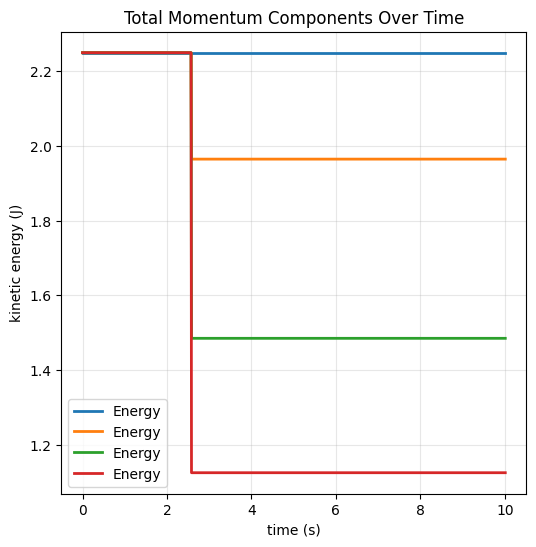

Percentage of kinetic energy loss: (e=1.0): 0.0%.
Percentage of kinetic energy loss: (e=0.9): 12.666666666666673%.
Percentage of kinetic energy loss: (e=0.7): 34.00000000000001%.
Percentage of kinetic energy loss: (e=0.5): 50.0%.


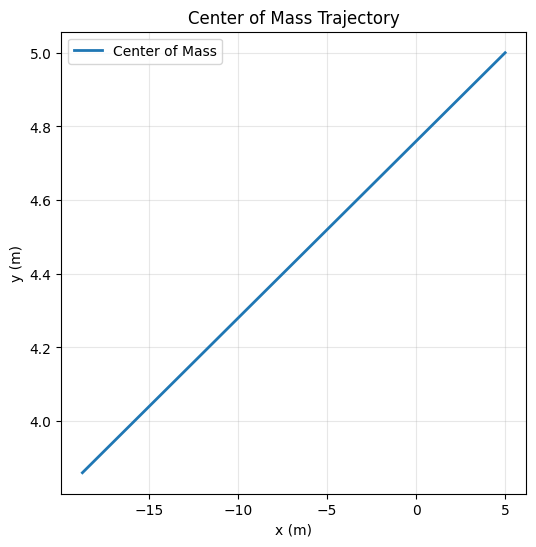

In [49]:
def simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,e,dt):
    t=0.0

    r1,r2=np.array(r1),np.array(r2)
    v1,v2=np.array(v1),np.array(v2)

    E=(0.5*m1)*(np.dot(v1,v1))+(0.5*m2)*(np.dot(v2,v2))
    P=m1*v1+m2*v2
    M=m1+m2
    V=P/M
    cen=np.array([(m1*r1[0]+m2*r2[0])/M,(m1*r1[1]+m2*r2[1])/M])

    pos=np.array([r1,r2])
    vel=np.array([v1,v2])

    t_arr,pos_arr,vel_arr,cen_arr,V_arr,E_arr,P_arr=[t],[pos.copy()],[vel.copy()],[cen.copy()],[V],[E],[P]

    while (t<=max_time):
        r1, r2 = pos[0], pos[1]
        v1, v2 = vel[0], vel[1]

        if overlapping(r1,r2,v1,v2,Rad1,Rad2):
            v1,v2=collide_2d(m1,m2,r1,r2,v1,v2,e)
            vel[0], vel[1] = v1, v2

        pos[0]=pos[0]+vel[0]*dt
        pos[1]=pos[1]+vel[1]*dt

        E=(0.5*m1)*(np.dot(vel[0],vel[0]))+(0.5*m2)*(np.dot(vel[1],vel[1]))
        P=m1*vel[0]+m2*vel[1]
        M=m1+m2
        V=P/M
        cen=np.array([(m1*pos[0]+m2*pos[0])/M,(m1*pos[1]+m2*pos[1])/M])

        t=t+dt

        t_arr.append(t)
        pos_arr.append(pos.copy())
        vel_arr.append(vel.copy())
        cen_arr.append(cen.copy())
        V_arr.append(V)
        E_arr.append(E)
        P_arr.append(P)
    return t_arr,pos_arr,vel_arr,cen,V_arr,E_arr,P_arr

r1,r2=np.array([1.0,5.0]),np.array([9.0,5.0])
v1,v2=np.array([1.0,0]),np.array([-2.0,0])


E0=simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,1.0,time_step)[5]
E1=simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,0.9,time_step)[5]
E2=simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,0.7,time_step)[5]
E3=simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,0.5,time_step)[5]

plt.figure(figsize=(6, 6))
plt.plot(t, E0, linewidth=2, label='Energy')
plt.plot(t, E1, linewidth=2, label='Energy')
plt.plot(t, E2, linewidth=2, label='Energy')
plt.plot(t, E3, linewidth=2, label='Energy')
plt.xlabel('time (s)')
plt.ylabel('kinetic energy (J)')
plt.title('Total Momentum Components Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Percentage of kinetic energy loss: (e=1.0): {((E0[0]-E0[-1])/E0[0])*100}%.')
print(f'Percentage of kinetic energy loss: (e=0.9): {((E1[0]-E1[-1])/E1[0])*100}%.')
print(f'Percentage of kinetic energy loss: (e=0.7): {((E2[0]-E2[-1])/E2[0])*100}%.')
print(f'Percentage of kinetic energy loss: (e=0.5): {((E3[0]-E3[-1])/E3[0])*100}%.')

cen=simulate(Rad1,Rad2,m1,m2,r1,r2,v1,v2,1.0,time_step)[3]

plt.figure(figsize=(6, 6))
plt.plot(cen[0], cen[1], linewidth=2, label='Center of Mass')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Center of Mass Trajectory')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Notes: The fact that the center of mass trajctory is essentially a particle moving at constant velocity is a great check for validity of the simulation because there are no forces on the particles, so there should be no change in momentum or momentum ought to be constant, which is the same as saying the system moves at constant velocity. Since CoM is like a mass-averaged trajectory, it should also move at constant velocity as nothing is being gained or taken.
In this simulation, the kinetic energy never increased for cases where e<1. If it did increase, it would mean the velocity of the particles would have to be increased in some manner, which suggests a bug in the code. Since there are no forces acting here, the velocities can only be reflected off of walls or balls, not increased and only diminished when e=/=1. This is a valid test simply because there is no physical reason, given the set-up, for the energy to increase-- the physical principles require it independent of exact solution.